In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import yfinance as yf
import pandas as pd
import seaborn as sns
import seaborn.objects as so
from keras import Input
from keras import layers, Model
import tensorflow as tf
from tensorflow.keras.optimizers import RMSprop, Adam, SGD
import random
import sys
sys.path.append('../..')
#import ep.etools as apt
# import warnings
# warnings.filterwarnings( "ignore", module = "matplotlib\..*" )
from tqdm import tqdm
from pandas.tseries.offsets import DateOffset,BusinessDay

,Day-ahead,Month-ahead,Quarter-ahead,Summer 24,Winter 24,Year-Ahead,2 Year-Ahead
date_m,,,,,,,
2010-01-01,14.30,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-04,16.25,13.70,NaN,NaN,NaN,NaN,NaN
2010-01-05,14.15,13.96,NaN,NaN,NaN,NaN,NaN
2010-01-06,14.65,13.80,NaN,NaN,NaN,NaN,NaN
2010-01-07,16.18,13.82,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2024-03-08,26.34,26.39,26.51,NaN,NaN,30.19,28.67
2024-03-11,25.02,24.97,25.10,25.33,29.56,29.19,27.78
2024-03-12,25.01,24.82,24.94,25.18,29.24,28.82,27.46


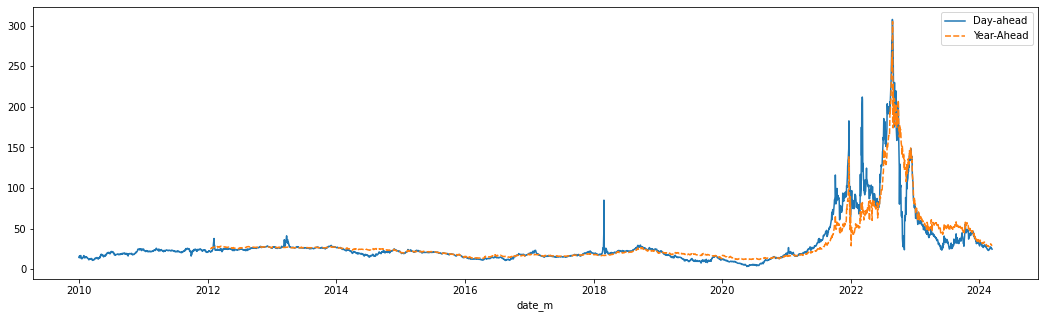

In [2]:
# dataCalendar = pd.read_csv('./data/bloc_ttf_calendar_prices.csv')
dataPrices = pd.read_csv('./data/bloc_ttf_prices.csv')
dataPrices['date_m'] = pd.to_datetime(dataPrices['date_m'])
dataPrices = dataPrices.set_index('date_m')
fig, ax = plt.subplots(figsize=(18,5))
# sns.set_palette("mako")
sns.lineplot(dataPrices[['Day-ahead','Year-Ahead']][0:-1], color='Blue'); #3390
#ax2 = plt.twinx()
#sns.lineplot(data=final['€/$'], ax=ax2 , color='grey')
dataPrices

# Lecture des informations de stock de Gaz depuis AGSI
* normalisation des données
* conversion en float
* conversion des dates

pour un Pays remplacer "type" par "country" et mettre en paramètre le code du pays : FR, BE, DE ...

In [257]:
import requests
params = {
    "type": "EU",
    "from": "2010-01-01",
    "size": 10000
}
header = {
  "x-key" : "99e18f932d22c9acf9c42f27d0b8b539" }

url = "https://agsi.gie.eu/api"
resp = requests.get(url=url, params=params, headers=header)
json = resp.json()
data = pd.json_normalize(json['data'])
data["gasInStorage"] = data["gasInStorage"].astype(float)
data["full"] = data["full"].astype(float)
#data["coveredCapacity"] = data["coveredCapacity"].astype(float)
data['date'] =pd.to_datetime(data['gasDayStart'], errors='coerce')
data = data.set_index(data['date'])
#data[["gasDayStart","gasInStorage"]]
#print(data)
print('Done')

Done


In [258]:
data

,name,code,url,updatedAt,gasDayStart,gasInStorage,consumption,consumptionFull,injection,withdrawal,...,injectionCapacity,withdrawalCapacity,contractedCapacity,availableCapacity,coveredCapacity,status,trend,full,info,date
date,,,,,,,,,,,,,,,,,,,,,
2024-03-31,EU,eu,eu,2024-04-01 19:02:11,2024-03-31,670.0945,3760.87,17.82,2865.91,873.6,...,11648.77,19898.51,-,-,100,E,-0.01,58.72,[],2024-03-31
2024-03-30,EU,eu,eu,2024-04-01 19:01:05,2024-03-30,670.2626,3760.87,17.82,1398.33,938.8,...,11468.13,19628.07,-,-,100,E,0.04,58.81,[],2024-03-30
2024-03-29,EU,eu,eu,2024-04-01 19:01:20,2024-03-29,669.8098,3760.87,17.81,1168.08,1233.9,...,11665.31,19923.38,-,-,100,E,-0.01,58.69,[],2024-03-29
2024-03-28,EU,eu,eu,2024-04-01 19:01:35,2024-03-28,669.9016,3760.87,17.81,717.46,1938.3,...,11665.23,19927.05,-,-,100,E,-0.11,58.70,[],2024-03-28
2024-03-27,EU,eu,eu,2024-04-01 19:01:54,2024-03-27,671.1521,3760.87,17.85,704.42,1803.2,...,11665.17,19923.74,-,-,100,E,-0.1,58.81,[],2024-03-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011-01-05,EU,eu,eu,2023-04-18 10:46:51,2011-01-05,428.0276,3530,12.13,62.45,3640.9,...,5392.47,10316.05,-,-,-,C,-0.58,69.32,[],2011-01-05
2011-01-04,EU,eu,eu,2023-04-18 10:46:51,2011-01-04,431.5952,3530,12.23,44.25,3829.5,...,5392.62,10316.06,-,-,-,C,-0.6,69.89,[],2011-01-04
2011-01-03,EU,eu,eu,2023-04-18 10:46:51,2011-01-03,435.3212,3530,12.33,110.6,3323.2,...,5392.74,10316.04,-,-,-,C,-0.51,70.50,[],2011-01-03


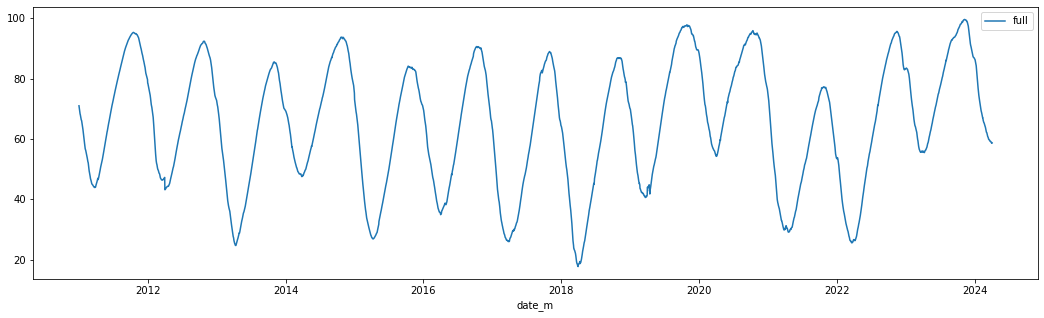

In [260]:
data['date_m'] = pd.to_datetime(data['gasDayStart'])
data = data.set_index('date_m')
fig, ax = plt.subplots(figsize=(18,5))
# sns.set_palette("mako")
sns.lineplot(data[['full']][0:-1], color='Blue'); #3390

# Détermination du caractère Stationnaire de l'évolution du stockage de Gaz ...

In [261]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error

In [262]:
def adf_test(serie):
    adf = adfuller(serie,autolag='AIC')
    print('Test Dickey Fuller')
    print('Test adf',adf[0])
    print('p-Value',adf[1],' Mac Kinnon')
    print('used Lags',adf[2])
    print('Number of obs',adf[3])
    for k,v in adf[4].items():
        print('critical value',k,'->',v)
    print('max Info',adf[5])    

In [263]:
def kpss_test(serie):
    kpss_ = kpss(serie,regression="c", nlags="auto")
    print('Test KPSS')
    print('Test kpss',kpss_[0])
    print('p-Value',kpss_[1])
    print('used Lags',kpss_[2])
    for k,v in kpss_[3].items():
        print('critical value',k,'->',v)

In [264]:
data.dropna()
adf_test(data['full'])


Test Dickey Fuller
Test adf -9.621861030245116
p-Value 1.7006354864328085e-16  Mac Kinnon
used Lags 30
Number of obs 4808
critical value 1% -> -3.431710814205638
critical value 5% -> -2.8621413274433674
critical value 10% -> -2.5670900882351515
max Info -5434.86528038671


In [265]:
kpss_test(data['full'])

Test KPSS
Test kpss 0.20495175393835163
p-Value 0.1
used Lags 42
critical value 10% -> 0.347
critical value 5% -> 0.463
critical value 2.5% -> 0.574
critical value 1% -> 0.739


/var/folders/vw/2g_98rts7tzczmvh5hqt_qn00000gn/T/ipykernel_87531/2657295217.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_ = kpss(serie,regression="c", nlags="auto")


Test Dickey Fuller
Test adf -2.331238172490048
p-Value 0.1620908446940354  Mac Kinnon
used Lags 5
Number of obs 699
critical value 1% -> -3.439739809554328
critical value 5% -> -2.86568368980381
critical value 10% -> -2.5689766074363334
max Info 4979.920656264398
Test KPSS
Test kpss 1.264318530673321
p-Value 0.01
used Lags 17
critical value 10% -> 0.347
critical value 5% -> 0.463
critical value 2.5% -> 0.574
critical value 1% -> 0.739


/var/folders/vw/2g_98rts7tzczmvh5hqt_qn00000gn/T/ipykernel_87531/2657295217.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_ = kpss(serie,regression="c", nlags="auto")


date_m
2021-07-02    36.30
2021-07-05    37.72
2021-07-06    33.99
2021-07-07    32.71
2021-07-08    34.02
              ...  
2024-03-08    26.34
2024-03-11    25.02
2024-03-12    25.01
2024-03-13    24.54
2024-03-14    25.34
Name: Day-ahead, Length: 705, dtype: float64

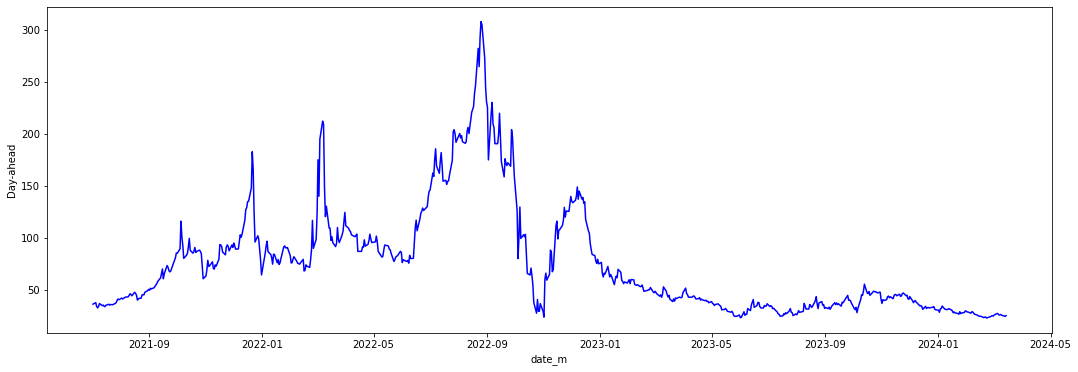

In [266]:
fig = plt.figure(figsize=(18,6))
sns.lineplot(data=dataPrices['Day-ahead'][3000:].dropna(),color='Blue')
adf_test(dataPrices['Day-ahead'][3000:].dropna())
kpss_test(dataPrices['Day-ahead'][3000:])
dataPrices['Day-ahead'][3000:]

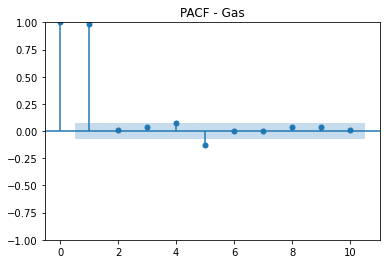

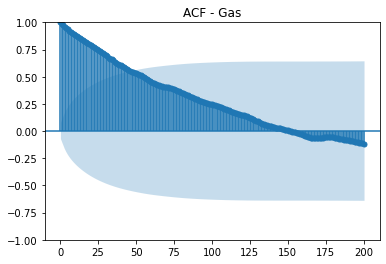

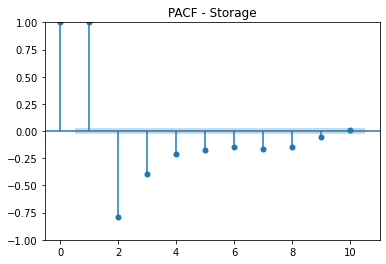

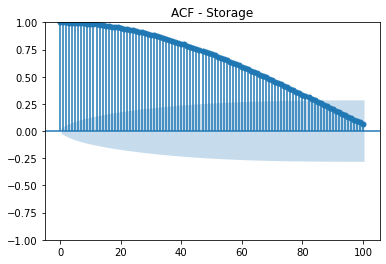

In [267]:
plot_pacf(dataPrices['Month-ahead'][3000:].dropna(),lags=10,title='PACF - Gas')
plot_acf(dataPrices['Month-ahead'][3000:].dropna(),lags=200,title='ACF - Gas')
plot_pacf(data['full'],lags=10,title='PACF - Storage')
plot_acf(data['full'],lags=100,title='ACF - Storage')
plt.show()

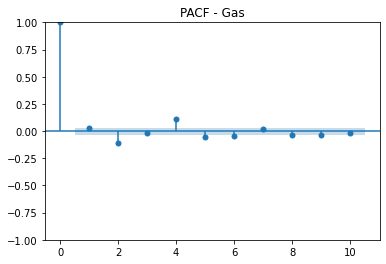

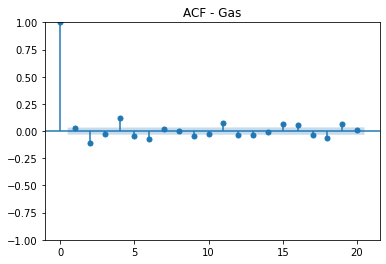

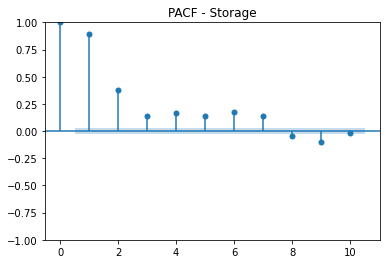

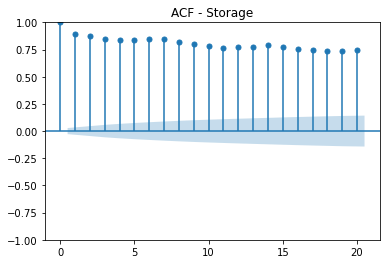

In [309]:
pricesDiff = dataPrices['Day-ahead'].diff().dropna()
dataDiff = data['full'][::-1].diff().dropna()
plot_pacf(pricesDiff,lags=10,title='PACF - Gas')
plot_acf(pricesDiff,lags=20,title='ACF - Gas')
plot_pacf(dataDiff,lags=10,title='PACF - Storage')
plot_acf(dataDiff,lags=20,title='ACF - Storage')
plt.show();

# Prévision de l'avolution du stockage

In [300]:
model=AutoReg(dataPrices['Day-ahead'][:],lags=120).fit()
model.summary()

/Users/rky/miniforge3/envs/tf-M1/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:              Day-ahead   No. Observations:                 3705
Model:                   AutoReg(120)   Log Likelihood               -9972.813
Method:               Conditional MLE   S.D. of innovations              3.907
Date:                Mon, 01 Apr 2024   AIC                          20189.625
Time:                        23:14:55   BIC                          20944.136
Sample:                    06-18-2010   HQIC                         20458.573
                         - 03-14-2024                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1715      0.095      1.803      0.071      -0.015       0.358
Day-ahead.L1       1.0190      0.017     61.098      0.000       0.986       1.052
Day-ahead.L2      -0.1027      0.024     -4.313      0.000      -0.149      -0.056
Day-ahead.L3       0.0505      0.024      2.118      0.034       0.004       0.097
Day-ahead.L4       0.1379      0.024      5.794      0.000       0.091       0.185
Day-ahead.L5      -0.1660      0.024     -6.952      0.000      -0.213      -0.119
Day-ahead.L6       0.0042      0.024      0.174      0.862      -0.043       0.051
Day-ahead.L7       0.0687      0.024      2.859      0.004       0.022       0.116
Day-ahead.L8      -0.0250      0.024     -1.040      0.298      -0.072       0.022
Day-ahead.L9       0.0092      0.024      0.381      0.703      -0.038       0.056
Day-ahead.L10     -0.0237      0.024     -0.985      0.324      -0.071       0.023
Day-ahead.L11      0.0708      0.024      2.943      0.003       0.024       0.118
Day-ahead.L12     -0.0908      0.024     -3.775      0.000      -0.138      -0.044
Day-ahead.L13      0.0589      0.024      2.448      0.014       0.012       0.106
Day-ahead.L14     -0.0248      0.024     -1.030      0.303      -0.072       0.022
Day-ahead.L15      0.0338      0.024      1.406      0.160      -0.013       0.081
Day-ahead.L16      0.0336      0.024      1.395      0.163      -0.014       0.081
Day-ahead.L17     -0.0775      0.024     -3.226      0.001      -0.125      -0.030
Day-ahead.L18     -0.0370      0.024     -1.539      0.124      -0.084       0.010
Day-ahead.L19      0.0936      0.024      3.893      0.000       0.046       0.141
Day-ahead.L20     -0.0623      0.024     -2.588      0.010      -0.109      -0.015
Day-ahead.L21     -0.0338      0.024     -1.402      0.161      -0.081       0.013
Day-ahead.L22      0.0909      0.024      3.773      0.000       0.044       0.138
Day-ahead.L23     -0.0032      0.024     -0.132      0.895      -0.050       0.044
Day-ahead.L24     -0.0296      0.024     -1.228      0.220      -0.077       0.018
Day-ahead.L25      0.0935      0.024      3.876      0.000       0.046       0.141
Day-ahead.L26     -0.1343      0.024     -5.560      0.000      -0.182      -0.087
Day-ahead.L27      0.0194      0.024      0.802      0.423      -0.028       0.067
Day-ahead.L28     -0.0252      0.024     -1.040      0.298      -0.073       0.022
Day-ahead.L29     -0.0178      0.024     -0.734      0.463      -0.065       0.030
Day-ahead.L30      0.0938      0.024      3.868      0.000       0.046       0.141
Day-ahead.L31     -0.0737      0.024     -3.034      0.002      -0.121      -0.026
Day-ahead.L32     -0.0119      0.024     -0.490      0.624      -0.060       0.036
Day-ahead.L33      0.0747      0.024      3.073      0.002       0.027       0.122
Day-ahead.L34     -0.0578      0.024     -2.376      0.017      -0.106      -0.010
Day-ahead.L35      0.0518      0.024      2.127      0.033       0.004       0.100
Day-

RMSE 2.0484675754312356


/Users/rky/miniforge3/envs/tf-M1/lib/python3.10/site-packages/statsmodels/tsa/deterministic.py:302: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


<AxesSubplot:xlabel='date_m', ylabel='Day-ahead'>

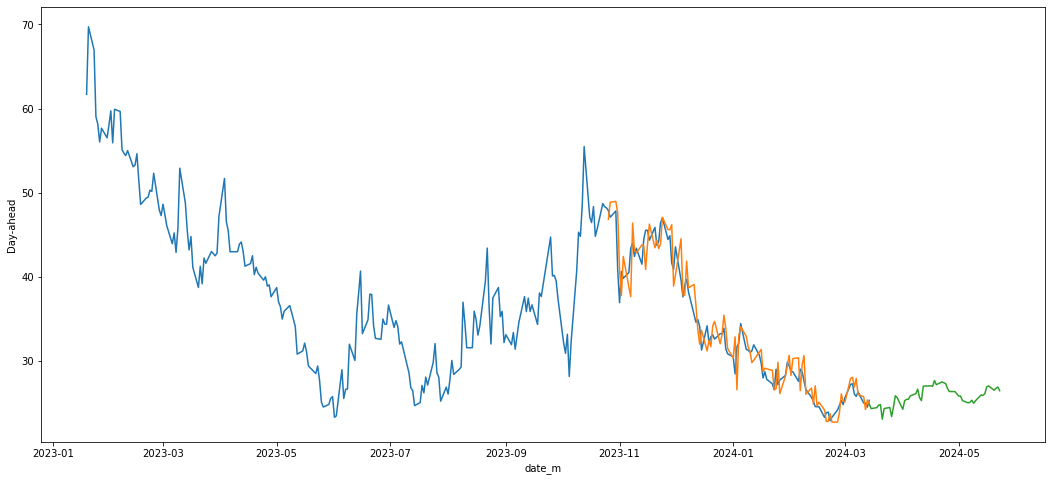

In [301]:
vmin= 3604
vmax=3704
control = model.predict(start=vmin,end=vmax,dynamic=False)
futur = model.predict(start=vmax,end=(vmax+50),dynamic=False)
rmse = math.sqrt(mean_squared_error(dataPrices['Day-ahead'][vmin:(vmax+1)],control))
print('RMSE',rmse)
fig = plt.figure(figsize=(18,8))
sns.lineplot(dataPrices['Day-ahead'][(vmin-200):])
sns.lineplot(control)
sns.lineplot(futur)

# ARIMA model

In [ ]:
#!pip install pmdarima

In [270]:
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

In [314]:
# all = dataPrices['Day-ahead'].dropna()
all = pricesDiff #data['full'][::-1].diff().dropna()
train = all.iloc[:-30]
test = all.iloc[-30:]
step = auto_arima(all,trace=True,suppress_warnings=True)
step.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=21065.598, Time=1.02 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=21168.842, Time=0.10 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=21168.042, Time=0.16 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=21167.290, Time=0.18 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=21166.843, Time=0.09 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=21136.408, Time=0.50 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=21128.600, Time=0.36 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=21064.071, Time=1.00 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=21109.569, Time=0.77 sec
 ARIMA(4,0,2)(0,0,0)[0] intercept   : AIC=21060.965, Time=1.06 sec
 ARIMA(4,0,1)(0,0,0)[0] intercept   : AIC=21076.177, Time=0.60 sec
 ARIMA(5,0,2)(0,0,0)[0] intercept   : AIC=21061.464, Time=1.83 sec
 ARIMA(4,0,3)(0,0,0)[0] intercept   : AIC=21057.523, Time=2.26 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=21061.960, Time=1.33 sec
 ARIMA(5,0,3)(0,0,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 3704
Model:               SARIMAX(5, 0, 3)   Log Likelihood              -10515.547
Date:                Tue, 02 Apr 2024   AIC                          21049.094
Time:                        22:39:46   BIC                          21105.048
Sample:                    01-04-2010   HQIC                         21069.006
                         - 03-14-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6202      0.027     23.061      0.000       0.568       0.673
ar.L2         -0.1440      0.029     -4.890      0.000      -0.202      -0.086
ar.L3          0.4313      0.027     16.211      0.000       0.379       0.483
ar.L4          0.1146      0.006     17.714      0.000       0.102       0.127
ar.L5         -0.0831      0.006    -15.024      0.000      -0.094      -0.072
ma.L1         -0.5869      0.028    -21.262      0.000      -0.641      -0.533
ma.L2          0.0347      0.029      1.197      0.231      -0.022       0.092
ma.L3         -0.4145      0.026    -15.731      0.000      -0.466      -0.363
sigma2        17.0958      0.076    225.443      0.000      16.947      17.244
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):            684625.20
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):              75.88   Skew:                             0.43
Prob(H) (two-sided):                  0.00   Kurtosis:                        69.60
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [315]:
all.describe()

count    3704.000000
mean        0.002981
std         4.213196
min       -60.020000
25%        -0.350000
50%         0.000000
75%         0.350000
max        54.820000
Name: Day-ahead, dtype: float64

/Users/rky/miniforge3/envs/tf-M1/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/Users/rky/miniforge3/envs/tf-M1/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/rky/miniforge3/envs/tf-M1/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/rky/miniforge3/envs/tf-M1/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              Day-ahead   No. Observations:                 3674
Model:                 ARIMA(5, 0, 3)   Log Likelihood              -10444.480
Date:                Tue, 02 Apr 2024   AIC                          20908.960
Time:                        22:40:08   BIC                          20971.051
Sample:                    01-04-2010   HQIC                         20931.065
                         - 02-01-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0119      0.062      0.192      0.847      -0.109       0.133
ar.L1          0.6218      0.025     24.512      0.000       0.572       0.672
ar.L2         -0.1959      0.028     -6.943      0.000      -0.251      -0.141
ar.L3          0.4894      0.025     19.680      0.000       0.441       0.538
ar.L4          0.1057      0.007     15.919      0.000       0.093       0.119
ar.L5         -0.0769      0.006    -13.768      0.000      -0.088      -0.066
ma.L1         -0.5892      0.026    -22.687      0.000      -0.640      -0.538
ma.L2          0.0866      0.028      3.143      0.002       0.033       0.141
ma.L3         -0.4706      0.024    -19.224      0.000      -0.519      -0.423
sigma2        17.2210      0.077    222.413      0.000      17.069      17.373
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):            669017.26
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):              76.61   Skew:                             0.51
Prob(H) (two-sided):                  0.00   Kurtosis:                        69.10
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

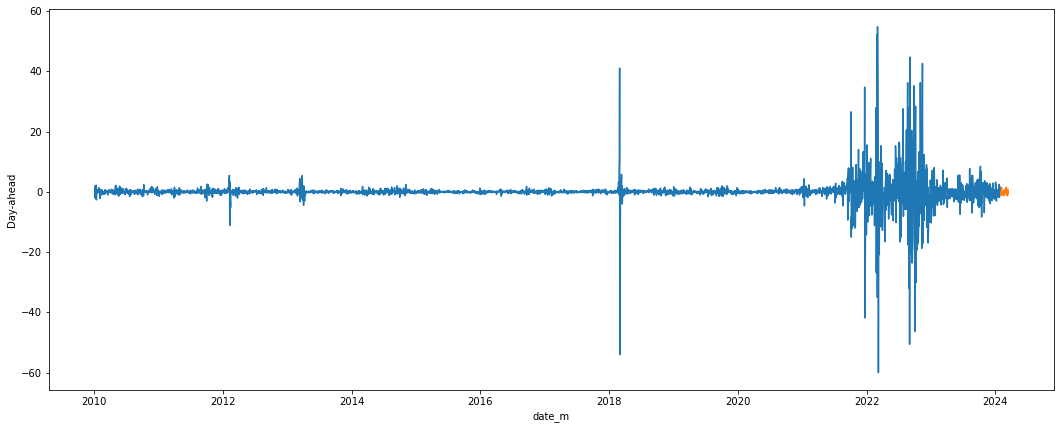

In [316]:
# print(train.shape)
fig = plt.figure(figsize=(18,7))
sns.lineplot(train[:]);
sns.lineplot(test[:]);
model = ARIMA(train,order=(5,0,3))
model = model.fit()
model.summary()

/Users/rky/miniforge3/envs/tf-M1/lib/python3.10/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['type']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


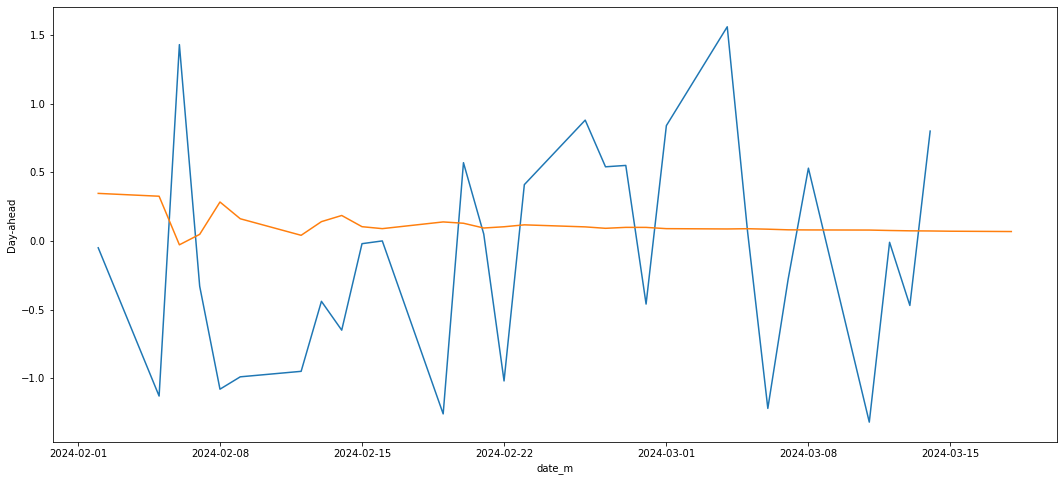

In [319]:
start = len(train)
end = start + len(test) + 1
pred = model.predict(start=start, end=end, type='levels')
fig = plt.figure(figsize=(18,8))
sns.lineplot(train[4000:]);
sns.lineplot(test);
sns.lineplot(pred);
# pred

# Extraire la saisonnaité

In [302]:
from statsmodels.tsa.seasonal import seasonal_decompose

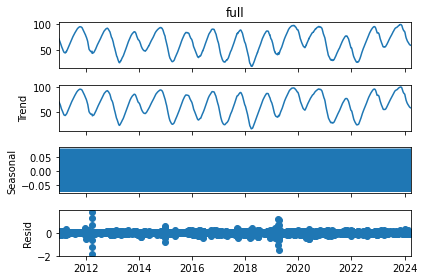

In [321]:
saison = seasonal_decompose(data['full'][::-1].dropna())
saison.plot();

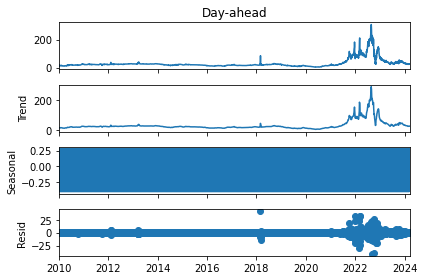

In [322]:
saison = seasonal_decompose(dataPrices['Day-ahead'].dropna())
saison.plot();